In [ ]:
from teachgrav.laws.true_law import flat_law, law
from teachgrav.laws.gp import GPModel
from teachgrav.scenarios import ScenarioFactory
import matplotlib.pyplot as plt
import numpy as np

In [2]:
factory = ScenarioFactory('numpy')
model = GPModel(factory)


In [11]:
model.train(1024, n_bodies=2, fixed_masses=[1.0, 1.0])


In [12]:
masses = factory.engine.np.array([1.0, 1.0])
immobile = factory.engine.np.array([False, False])


In [13]:
scenario = factory.create_scenario('scatter', n_bodies=2,
                                    fixed_masses=masses)
gp_res = model.gp_law(scenario)
res = law(scenario)
print("GP result:\n", gp_res)
print("True result:\n", res)
assert gp_res.shape == res.shape

Scales: X mean: [ 0.0050319   0.00815528 -0.0050319  -0.00815528  0.00504831 -0.00350819
 -0.00504831  0.00350819] X std: [0.42145334 0.41238248 0.42145334 0.41238248 0.40657532 0.39470096
 0.40657532 0.39470096]
Scales: Y mean: [ 0.14601822  0.53597928 -0.14601822 -0.53597928] Y std: [ 9.46119869 21.98122969  9.46119869 21.98122969]
GP predicted accelerations: [-0.16156941  0.0096985   0.16156941 -0.0096985 ]
Current velocities: [-0.21076374  0.04805903  0.21076374 -0.04805903]
GP result:
 [[[-0.21076374  0.04805903]
  [ 0.21076374 -0.04805903]]

 [[-0.16156941  0.0096985 ]
  [ 0.16156941 -0.0096985 ]]]
True result:
 [[[-0.21076374  0.04805903]
  [ 0.21076374 -0.04805903]]

 [[-0.30562103 -0.25978715]
  [ 0.30562103  0.25978715]]]


In [14]:
def plot(ranges, fn, np=np):

    x = np.linspace(ranges[0][0], ranges[0][1], 200)
    y = np.linspace(ranges[1][0], ranges[1][1], 200)
    X, Y = np.meshgrid(x, y)
    Z = fn(X, Y)
    plt.style.use("dark_background")

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none")

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.set_zlabel("$f(x, y)$")
    fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1)

    plt.show()

In [15]:
# Show some partial cuts across the data

# The law, for fixed x0, y0, vx0, vy0, vx1, vy1, as a function of x1, y1,
# shwoing the acceeration of body 0 in the x direction.
def cut(x1, y1):
    x1f = x1.flatten()
    y1f = y1.flatten()
    z = factory.engine.np.zeros(x1f.shape)
    ICs = factory.engine.np.stack([z, z, x1f, y1f, z, z, z, z],axis=1)
    print("ICs shape:", ICs.shape)
    result = flat_law(ICs, masses, immobile).reshape(len(x1f), 2, 2, 2)
    return result[:,1, 0, 0].reshape(x1.shape) # x accelerations of body 0
cut(factory.engine.np.array([[0, 0],[1,1]]),factory.engine.np.array([[0, 1],[0,1]]))

ICs shape: (4, 8)


array([[0.        , 0.        ],
       [1.        , 0.35355339]])

ICs shape: (40000, 8)


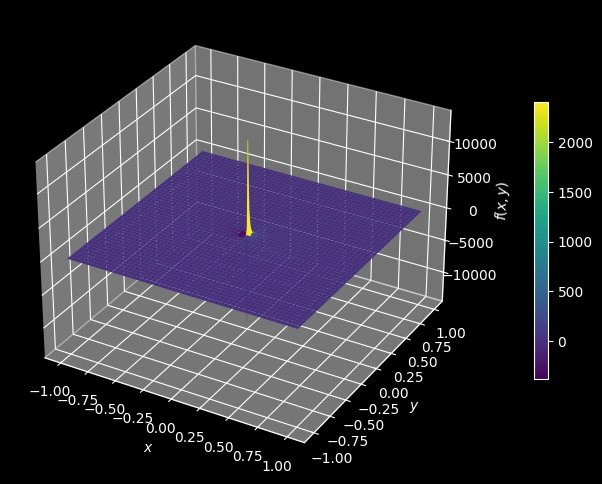

In [16]:
plot([[-1, 1], [-1, 1]], cut, np=factory.engine.np)

In [17]:
def cut(x1, y1):
    x1f = x1.flatten()
    y1f = y1.flatten()
    z = factory.engine.np.zeros(x1f.shape)
    ICs = factory.engine.np.stack([z, z, x1f, y1f, z, z, z, z],axis=1)
    result = model.gp_flat_law(ICs, masses, immobile)
    result = result.reshape(len(x1f), 2, 2, 2)
    return result[:,1, 0, 0].reshape(x1.shape) # x accelerations of body 0
cut(factory.engine.np.array([[0, 0],[1,1]]),factory.engine.np.array([[0, 1],[0,1]]))

array([[8.73785938, 0.14547016],
       [0.15425889, 0.14609863]])

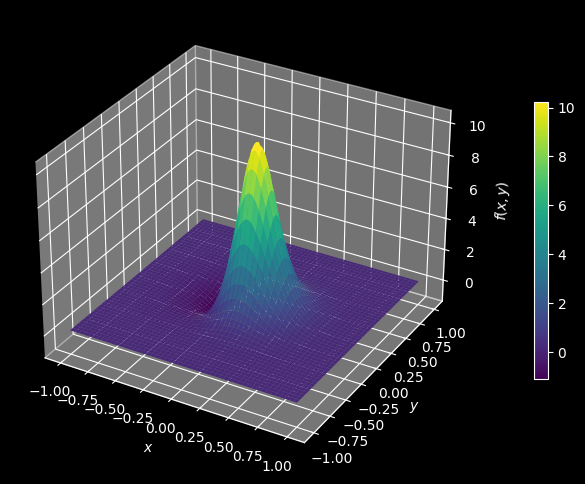

In [18]:
plot([[-1, 1], [-1, 1]], cut, np=factory.engine.np)